**Step 1 | Load Library**

In [1]:
# IMD Python Project Pipeline
# Load libraries
# Removing the warnings from the cells by importing the warnings module
import warnings
warnings.filterwarnings('ignore')  # Setting up a filter to ignore warnings. Good if you are confident with the codes

#import the necessary libraries
import pandas as pd # For the manipulation of tabular data
import numpy as np # For improved numerical calculation
from ydata_profiling import ProfileReport # For exploratory data analysis reporting
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For improved plot outlook
from matplotlib.colors import ListedColormap
%matplotlib inline 
#Tells Jupyter to display any matplotlib plots directly within the notebook, rather than in a separate. Alt: plt.show()

from sklearn.model_selection import train_test_split
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline

# Importing the scaler
from sklearn.preprocessing import StandardScaler

# Importing required models and metrics

from sklearn.model_selection import StratifiedKFold, cross_val_score

# Importing classifiers based on their functionalities

# Logistic Regression: A linear model for classification tasks, often used for binary classification
from sklearn.linear_model import LogisticRegression  
# Gaussian Naive Bayes: A probabilistic classifier based on Bayes' theorem with Gaussian distribution assumption
from sklearn.naive_bayes import GaussianNB  
# K-Nearest Neighbors: A non-parametric method used for classification based on nearest training examples
from sklearn.neighbors import KNeighborsClassifier  
# Decision Tree: A non-linear model that partitions the feature space into regions to make predictions
from sklearn.tree import DecisionTreeClassifier  
# Support Vector Classifier: A powerful classifier that finds the hyperplane that best separates classes in high-dimensional space
from sklearn.svm import SVC  
# Importing ensemble classifiers
# Random Forest: An ensemble method that builds multiple decision trees and combines their predictions
from sklearn.ensemble import RandomForestClassifier  
# Gradient Boosting Classifier: An ensemble method that builds trees sequentially, each correcting the mistakes of the previous one
from sklearn.ensemble import GradientBoostingClassifier  
# AdaBoost Classifier: An ensemble method that combines multiple weak learners to build a strong classifier
from sklearn.ensemble import AdaBoostClassifier  

In [2]:
# Set the resolution of the plotted figures
plt.rcParams['figure.dpi'] = 200

# Configure Seaborn plot styles: Set background color and use dark grid
sns.set_theme(rc={'axes.facecolor': '#faded9'}, style='darkgrid')

**Step 2 | Read Dataset**

In [3]:
import pandas as pd

# Define columns and their respective data types; str = strings, floats = numericals
dtype_mapping = {
    'PatientID': str,'Age': float, 'AgeCategory': str, 'Gender_of_Child': str, 'Religion': str,
       'Childs_Education_Level': str, 'BMI_category': str, 'childtrib1': str, 'orphanhood': str,
       'Socio_Economic_Status': str, 'Support_Program': str, 'Child_Takes_ART': str, 'Worst_HIV_Stage': str,
       'Premature_Birth': str, 'Born_with_HIV': str, 'Stress': str, 'GroupCategory': str,
       'cd4takeoff1': float, 'CD4_category': str, 'Viralload': float, 'Viralload_Category': str,
       'Baseline_telomere_length': float, 'Telomere_length_12Months': float, 'tldiff': float,
       'telomere_length_change': str, 'stin2vntr_': str, 'httlpr1_polymorphism': str,
       'HTTLPRrs35531': str, 'rs35531_polymorphism': str, 'Rs10482605_polymorphism': str,
       'Rs1360780_polymorphism': str, 'rs1386494_polymorphism': str, 'rs1843809_polymorphism': str, 'rs34517220_polymorphism': str,
       'rs4570625_polymorphism': str,'GroupCategory':str,'GAD': float, 'MDD': float, 'PTSD': float,'IMDs': float
       }

# Read the CSV file with specified data types
IMD_Dataset = pd.read_csv("DATA ML PERSISTENT NEW NEW 30 SEP.csv", dtype=dtype_mapping, encoding='latin1')

# Display the first few rows of the DataFrame
IMD_Dataset.head(3)

,PatientID,Age,AgeCategory,Gender_of_Child,Religion,Childs_Education_Level,BMI_category,childtrib1,orphanhood,Socio_Economic_Status,...,Rs1360780_polymorphism,rs1386494_polymorphism,rs1843809_polymorphism,rs34517220_polymorphism,rs4570625_polymorphism,GroupCategory,GAD,MDD,PTSD,IMDs
0,CHAKA/05/07/0433,14.00000,Children,Male,Christians,Pre-primary,Underweight,Non-Munganda but Ugandan,Single parent alive,high socioecnomic status,...,NaN,NaN,NaN,NaN,G:G,cases,0.0,0.0,0.0,0.0
1,CHAKA/02/03/0392,10.00684,Adolescent,Female,Christians,Pre-primary,Underweight,Muganda,Both parents alive,high socioecnomic status,...,NaN,NaN,T:T,NaN,G:G,cases,0.0,0.0,0.0,0.0
2,CHAKA/01/01/0001,11.66872,Adolescent,Female,Christians,Pre-primary,Underweight,Non-Munganda but Ugandan,Single parent alive,high socioecnomic status,...,C:T,A:A,G:G,A:A,G:G,cases,0.0,0.0,0.0,0.0


DATA PRE-PROCESSING

In [4]:
#Dropping Non-Important and Redundant Variables 
# List of variables to drop

columns_to_drop = ['PatientID','GroupCategory', 'Age', 'cd4takeoff1','Viralload', 'tldiff', 'GAD', 'MDD', 'PTSD']

# Dropping the specified columns
IMD_Dataset2 = IMD_Dataset.drop(columns=columns_to_drop)

**Outlier Treatment**

**IMPUTATIONS OF MISISNG VALUES**

- The SimpleImputer was the best choice to be used.

Observations from pandas profiling
- `General Statistics:` There were about 29 variables. with 368 observations. The missing cells composed of 6.5%. There were no duplicates.
- `Presence of a highly imbalanced variable:` There were over 15 varaibles that were imbalanced and this informed our decision on the metrcs for selcetion of best model

In [5]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Separate features and target variable
IMD_2 = IMD_Dataset2.copy()
# Identify numerical and categorical (object) columns
numerical_cols = IMD_2.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = IMD_2.select_dtypes(include=['object']).columns

# Impute missing values for numerical columns
numerical_imputer = SimpleImputer(strategy='mean')
numerical_imputed = pd.DataFrame(numerical_imputer.fit_transform(IMD_2[numerical_cols]), columns=numerical_cols)

# Impute missing values for categorical columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
categorical_imputed = pd.DataFrame(categorical_imputer.fit_transform(IMD_2[categorical_cols]), columns=categorical_cols)

# Combine imputed numerical and categorical columns
IMD_2_imputed = pd.concat([numerical_imputed, categorical_imputed], axis=1)

#Export the Imputed Data for STATA Analysis 
IMD_2_imputed.to_stata("Persistent_IMD_Imputed_Data.dta", version=118)

#Check for misisng vlaues again
IMD_2_imputed.isnull().sum().sum()

0

### 3. Prepare Data

a) Data Cleaning

b) Feature Selection

c) Data Transforms



In [6]:
IMD_2_imputed. columns

Index(['Baseline_telomere_length', 'Telomere_length_12Months', 'IMDs',
       'AgeCategory', 'Gender_of_Child', 'Religion', 'Childs_Education_Level',
       'BMI_category', 'childtrib1', 'orphanhood', 'Socio_Economic_Status',
       'Support_Program', 'Stress', 'Premature_Birth', 'Born_with_HIV',
       'Child_Takes_ART', 'Worst_HIV_Stage', 'CD4_category',
       'Viralload_Category', 'telomere_length_change', 'stin2vntr_',
       'httlpr1_polymorphism', 'HTTLPRrs35531', 'rs35531_polymorphism',
       'Rs10482605_polymorphism', 'Rs1360780_polymorphism',
       'rs1386494_polymorphism', 'rs1843809_polymorphism',
       'rs34517220_polymorphism', 'rs4570625_polymorphism'],
      dtype='object')

ENCODING

In [7]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import Normalizer, OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate features and target variable
IMD_Copy2 = IMD_2_imputed.copy()

# Label encode the IMD_Copy variable if it's categorical
for column in IMD_Copy2.columns:
    if IMD_Copy2[column].dtype == 'object' or IMD_Copy2[column].dtype.name == 'category':
        label_encoder = LabelEncoder()
        IMD_Copy2[column] = label_encoder.fit_transform(IMD_Copy2[column])
IMD_Copy2.head(5)

,Baseline_telomere_length,Telomere_length_12Months,IMDs,AgeCategory,Gender_of_Child,Religion,Childs_Education_Level,BMI_category,childtrib1,orphanhood,...,stin2vntr_,httlpr1_polymorphism,HTTLPRrs35531,rs35531_polymorphism,Rs10482605_polymorphism,Rs1360780_polymorphism,rs1386494_polymorphism,rs1843809_polymorphism,rs34517220_polymorphism,rs4570625_polymorphism
0,1.194107,1.077437,0.0,1,1,0,1,3,1,2,...,2,0,0,0,0,1,2,1,1,0
1,1.198068,0.621207,0.0,0,0,0,1,3,0,0,...,0,0,0,0,0,1,2,2,1,0
2,1.085470,1.038388,0.0,0,0,0,1,3,1,2,...,2,2,0,0,0,1,0,0,0,0
3,1.180387,1.532633,0.0,1,0,0,1,3,0,2,...,0,0,0,0,0,0,1,0,1,0
4,1.648820,0.865291,0.0,0,0,0,2,3,0,2,...,2,0,0,0,0,0,1,1,1,0


In [8]:
IMD_Copy2.columns

Index(['Baseline_telomere_length', 'Telomere_length_12Months', 'IMDs',
       'AgeCategory', 'Gender_of_Child', 'Religion', 'Childs_Education_Level',
       'BMI_category', 'childtrib1', 'orphanhood', 'Socio_Economic_Status',
       'Support_Program', 'Stress', 'Premature_Birth', 'Born_with_HIV',
       'Child_Takes_ART', 'Worst_HIV_Stage', 'CD4_category',
       'Viralload_Category', 'telomere_length_change', 'stin2vntr_',
       'httlpr1_polymorphism', 'HTTLPRrs35531', 'rs35531_polymorphism',
       'Rs10482605_polymorphism', 'Rs1360780_polymorphism',
       'rs1386494_polymorphism', 'rs1843809_polymorphism',
       'rs34517220_polymorphism', 'rs4570625_polymorphism'],
      dtype='object')

In [9]:
# List of variables to drop because of high correlation
columns_Psycho_drop = ['telomere_length_change', 'HTTLPRrs35531', 'rs35531_polymorphism',
                       'AgeCategory', 'Gender_of_Child', 'Religion', 'Childs_Education_Level',
       'BMI_category', 'childtrib1', 'orphanhood', 'Socio_Economic_Status',
       'Support_Program', 'Stress', 'Premature_Birth', 'Born_with_HIV',
       'Child_Takes_ART',
                        'stin2vntr_', 'httlpr1_polymorphism', 'Rs10482605_polymorphism', 
                       'Rs1360780_polymorphism', 'rs1386494_polymorphism', 
                       'rs1843809_polymorphism', 'rs34517220_polymorphism', 
                       'rs4570625_polymorphism']

# Load Data
IMD_Copy_Psycho = IMD_Copy2.drop(columns=columns_Psycho_drop)



In [10]:
# Separate features and target variable
features = IMD_Copy_Psycho.drop('IMDs', axis=1)
target = IMD_Copy_Psycho['IMDs']

# from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Instantiating the models
# dc = DummyClassifier(strategy='most_frequent')
lr = LogisticRegression()
nb = GaussianNB()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
sv = SVC(probability=True)  # Probability set to True to return a non-NaN roc_auc
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
# ad = AdaBoostClassifier()
# lda = LinearDiscriminantAnalysis()

from sklearn.model_selection import StratifiedKFold

# Setting the StratifiedKFold parameter
skfold = StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

# Define models and scores as you did
models = [lr, nb, knn, dt, sv, rf, gb]
scores = ["f1_weighted", "precision_weighted", "recall_weighted", "accuracy", "roc_auc_ovo_weighted"]

# Split the data into training and testing sets
# Assuming features and target are already defined
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize StratifiedKFold for cross-validation
n_splits = 10  # You can adjust this number as needed
skfold = StratifiedKFold(n_splits=n_splits, random_state=42, shuffle=True)


In [11]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize a dictionary to store the mean scores for each model
model_scores = {}
f1_scores = {}

# For loop to evaluate the models
for model in models:
    model_scores[model] = {}
    f1_scores[model] = []
    
    print(f"Evaluating model: {model}")
    for score in scores:
        cv_scores = cross_val_score(model, X_train, y_train, cv=skfold, scoring=score)
        mean_cv_score = np.mean(cv_scores)
        
        model_scores[model][score] = mean_cv_score
        if score == "f1_weighted":
            f1_scores[model].append(mean_cv_score)
        
        print(f"{score}: {mean_cv_score}")
    print("\n")

# Determine the model with the best F1 score
best_model_psycho = max(model_scores.keys(), key=lambda x: model_scores[x]["f1_weighted"])
print(f"Best model based on F1 Score: {best_model_psycho}")

# Fit the best model on the entire training data
best_model_instance2 = best_model_psycho  # Retrieve the actual model instance (ensure you are using the fitted instance)
best_model_instance2.fit(X_train, y_train)  # Fit the best model on the full training dataset


Evaluating model: LogisticRegression()
f1_weighted: 0.7008291209982817
precision_weighted: 0.6281856255780156
recall_weighted: 0.792528735632184
accuracy: 0.792528735632184
roc_auc_ovo_weighted: 0.5413172877846791


Evaluating model: GaussianNB()
f1_weighted: 0.6975172320782403
precision_weighted: 0.6583376208721036
recall_weighted: 0.7548275862068965
accuracy: 0.7548275862068965
roc_auc_ovo_weighted: 0.5063362663906141


Evaluating model: KNeighborsClassifier()
f1_weighted: 0.6796221089239792
precision_weighted: 0.6208973487867662
recall_weighted: 0.7516091954022989
accuracy: 0.7516091954022989
roc_auc_ovo_weighted: 0.4960209627329192


Evaluating model: DecisionTreeClassifier()
f1_weighted: 0.6694159353555644
precision_weighted: 0.6671968544781888
recall_weighted: 0.6425287356321838
accuracy: 0.6526436781609195
roc_auc_ovo_weighted: 0.5044254658385092


Evaluating model: SVC(probability=True)
f1_weighted: 0.7008291209982817
precision_weighted: 0.6281856255780156
recall_weighted: 0.79

LogisticRegression()

Accuracy on test dataset: 0.8243
Precision on test dataset: 0.6795
Recall on test dataset: 0.8243
F1-score on test dataset: 0.7449
AUC on test dataset: 0.5000


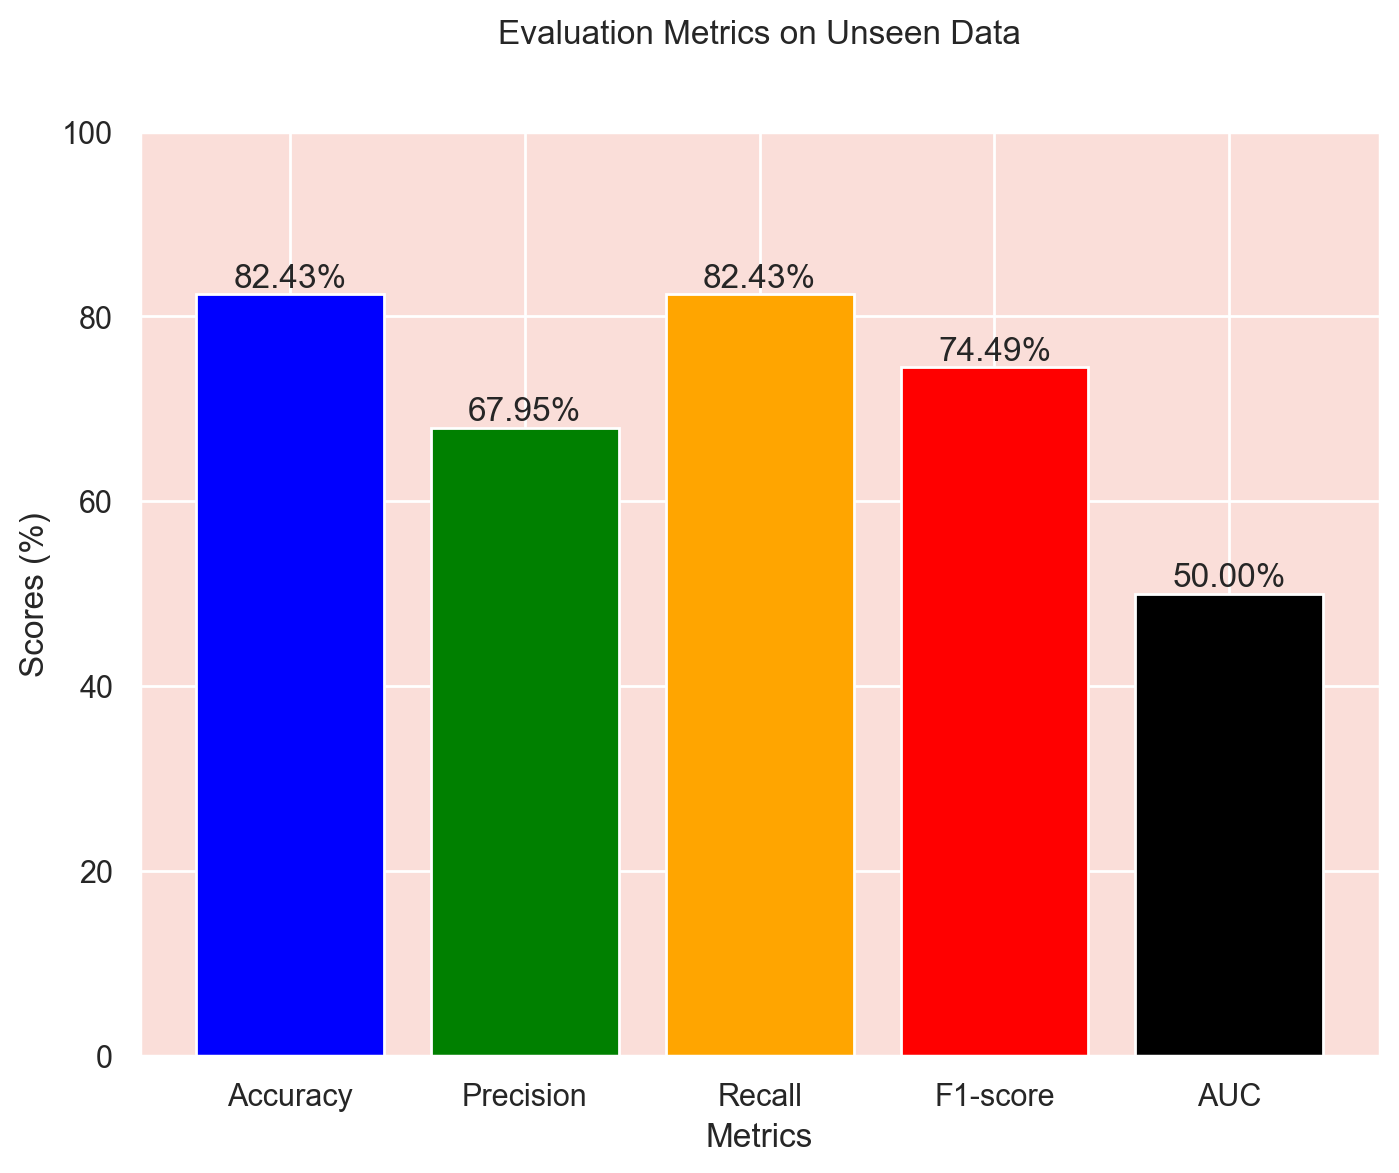

In [12]:
# Make predictions on the test dataset
y_pred_test = best_model_instance2.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, average='weighted')
recall = recall_score(y_test, y_pred_test, average='weighted')
f1 = f1_score(y_test, y_pred_test, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_test)  # Calculate AUC

# Print evaluation metrics
print(f"Accuracy on test dataset: {accuracy:.4f}")
print(f"Precision on test dataset: {precision:.4f}")
print(f"Recall on test dataset: {recall:.4f}")
print(f"F1-score on test dataset: {f1:.4f}")
print(f"AUC on test dataset: {roc_auc:.4f}")

# Prepare data for the metrics plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']
values = [accuracy, precision, recall, f1, roc_auc]

# Multiply scores by 100 to convert to percentage
scores_percentage = [value * 100 for value in values]

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(metrics, scores_percentage, color=['blue', 'green', 'orange', 'red', 'black'])

# Add more space between the chart title and the bar graph
plt.title('Evaluation Metrics on Unseen Data\n\n')

plt.xlabel('Metrics')
plt.ylabel('Scores (%)')  # Adjust y-axis label to indicate percentage
plt.ylim(0, 100)  # Set y-axis limit to range between 0 and 100 for percentages

# Add value labels on top of the bars
for bar, score in zip(bars, scores_percentage):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), '{:.2f}%'.format(score),
             ha='center', va='bottom')

plt.show()


Using 294 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/74 [00:00<?, ?it/s]

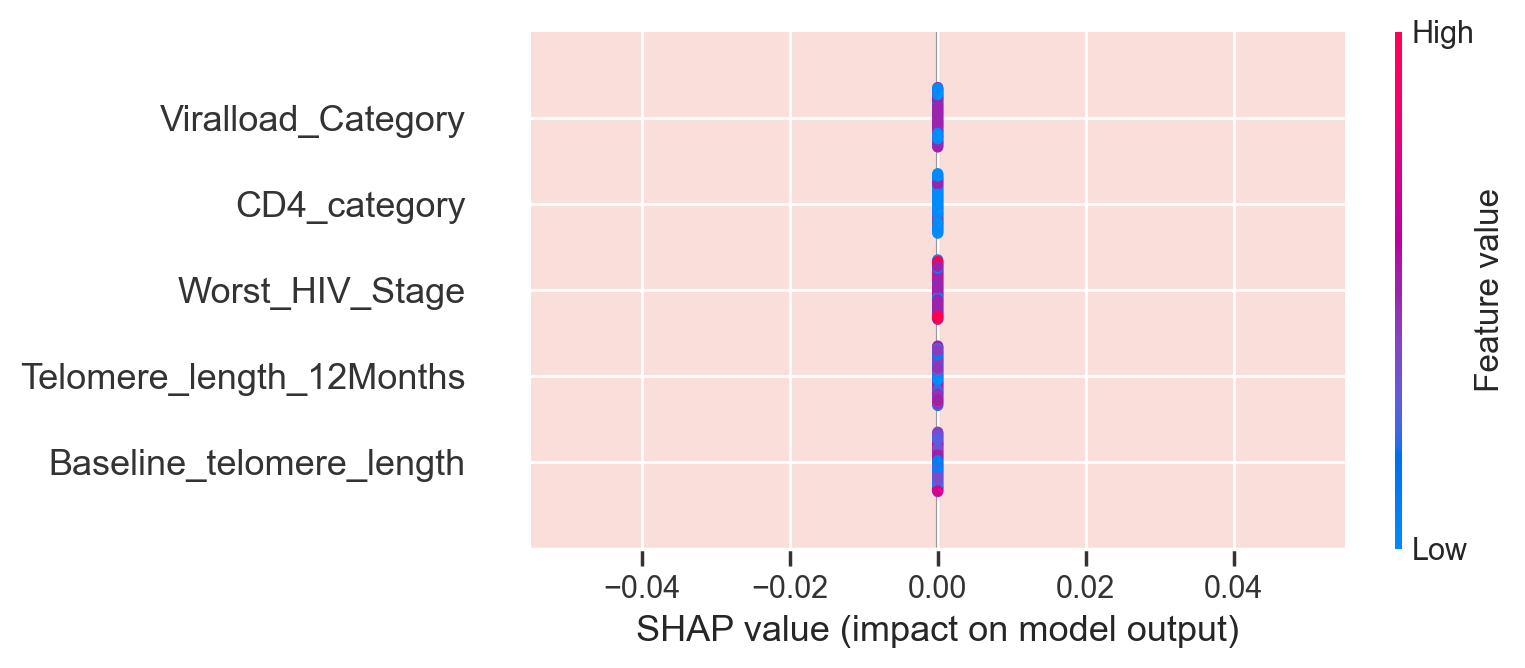

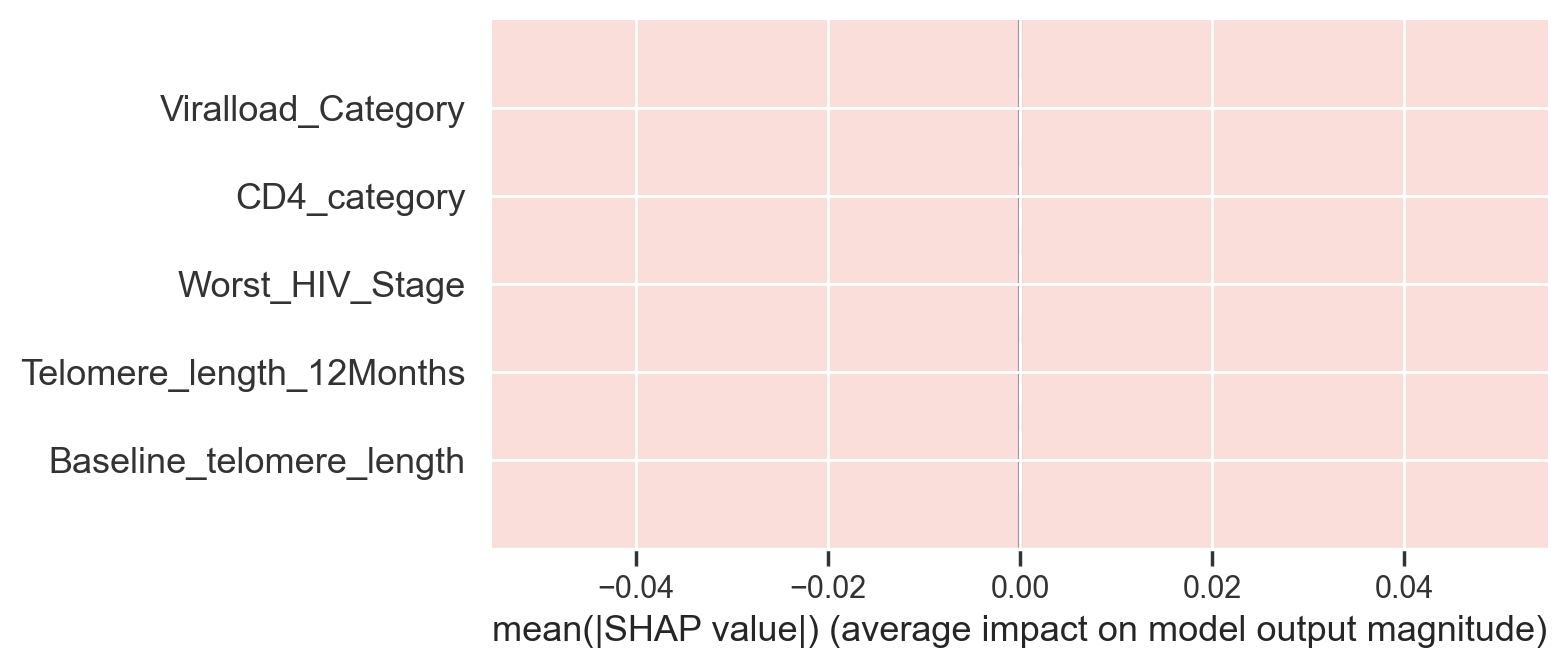

In [13]:
import shap

# Use KernelExplainer for a model that is not natively supported by SHAP
explainer = shap.KernelExplainer(best_model_instance2.predict, X_train)  # Use the predict method of the model

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary plot (bar or beeswarm)
shap.summary_plot(shap_values, X_test)

# Optional: You can also create a bar plot if you specifically want to display feature importance as a bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar")
